# ClimateWell-FuseNet V3: SPECTER2-Powered P100 GPU Notebook

This V3 keeps the cleaned data pipeline and the proven ClimateWell-FuseNet gated-fusion architecture from V2, and upgrades the scientific-document encoder from the original **SPECTER (2020)** to **SPECTER2 (2023, `allenai/specter2_base` + `allenai/specter2_classification` adapter)**.

SPECTER2 is a drop-in replacement: same `bert-base-uncased` backbone, same embedding dimension (768), same `title [SEP] abstract` input format. It is, however, trained on 6M citation triplets across 23 fields of study and 9 task formats, and the classification adapter is specifically trained for the exact downstream pattern used here (encode paper -> feed a small classifier head). On the SciRepEval benchmark this lifts the classification average from 54.7 to 62.3 with no change in parameter count, so it fits the P100 16 GB memory envelope identically.

All other components -- BGE-small-en branch, TF-IDF/SVD lexical branch, gated-fusion FuseNet head, hierarchical Accept/Reject + theme heads, theme-prototype similarity module, cross-validated ablations, and master-file calibration -- are left unchanged on purpose, so the lift in Stage-1 AP, accept-F1 and Stage-2 theme macro-F1 is attributable entirely to the upgraded scientific transformer.


## Expected contribution statement

You can use wording like this in your report:

> This study proposes **ClimateWell-FuseNet**, a hierarchical gated scientific-semantic fusion architecture for climate-policy well-being evidence classification. The model integrates general semantic embeddings (BGE), task-format-aware scientific-document embeddings (**SPECTER2 with the classification adapter**), and lexical policy features through trainable projection and gating layers. It jointly optimises binary relevance screening and accepted-only theme annotation, while a prototype-based theme module and uncertainty-aware review score support low-resource, imbalanced evidence annotation.


In [1]:
# ============================================================
# 0. Optional installs
# ============================================================
# On Kaggle/Colab, the next line installs the `adapters` package which is
# required to load SPECTER2 task-format adapters. Internet must be ON.
# `transformers` and `sentence-transformers` are already present on Kaggle.
import subprocess, sys
def _pip_install(pkgs):
    try:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + pkgs)
        return True
    except Exception as e:
        print('pip install failed:', e)
        return False

try:
    import adapters  # noqa: F401
    print('adapters already installed:', adapters.__version__)
except Exception:
    print('Installing adapters package for SPECTER2 ...')
    _pip_install(['adapters==0.2.2'])
    try:
        import adapters  # noqa: F401
        print('adapters installed:', adapters.__version__)
    except Exception as e:
        print('WARNING: adapters not available, will fall back to plain SPECTER2 base or original SPECTER. Reason:', e)


adapters already installed: 0.2.2


## P100 GPU-only setup

Run the next cell first in Kaggle with **Accelerator = GPU P100** and **Internet = On**. If your current PyTorch build cannot execute CUDA kernels on P100, the cell installs a CUDA 11.8 PyTorch build and restarts the kernel automatically. After the restart, run the notebook from the top again.

This notebook intentionally does **not** fall back to CPU. If CUDA is unavailable or unusable, it stops with an error.

In [2]:

# ============================================================
# P100 GPU-only PyTorch repair cell
# ============================================================
# Purpose: Kaggle sometimes ships a PyTorch/CUDA build that sees the P100
# but cannot execute kernels on compute capability 6.0. This cell verifies
# CUDA execution. If it fails, it installs a CUDA 11.8 PyTorch build and
# restarts the kernel. Re-run the notebook from the top after restart.

import os, sys, subprocess, textwrap


def _torch_cuda_smoke_test(verbose=True):
    try:
        import torch
        if verbose:
            print("Torch version:", torch.__version__)
            print("Torch CUDA build:", torch.version.cuda)
            print("CUDA available:", torch.cuda.is_available())
        if not torch.cuda.is_available():
            return False, "torch.cuda.is_available() is False"
        name = torch.cuda.get_device_name(0)
        cc = torch.cuda.get_device_capability(0)
        if verbose:
            print("GPU:", name, "| compute capability:", cc)
        # Actual kernel execution test. This is what failed in your traceback.
        x = torch.ones((128, 128), device="cuda", dtype=torch.float32)
        y = x @ x
        torch.cuda.synchronize()
        _ = float(y[0, 0].detach().cpu())
        return True, f"CUDA kernel test passed on {name}"
    except Exception as e:
        return False, repr(e)

ok, msg = _torch_cuda_smoke_test(verbose=True)
print("CUDA smoke test:", msg)

if not ok:
    print("\nInstalling a P100-compatible CUDA PyTorch build. This needs Kaggle Internet = On.")
    print("After installation, the kernel will restart automatically. Then run all cells again.\n")
    commands = [
        [sys.executable, "-m", "pip", "uninstall", "-y", "torch", "torchvision", "torchaudio", "triton"],
        [sys.executable, "-m", "pip", "install", "--no-cache-dir", "--force-reinstall",
         "torch==2.5.1", "torchvision==0.20.1", "torchaudio==2.5.1",
         "--index-url", "https://download.pytorch.org/whl/cu118"],
        [sys.executable, "-m", "pip", "install", "-q", "--upgrade",
         "transformers==4.46.3", "sentence-transformers==3.3.1", "accelerate==1.1.1"],
    ]
    for cmd in commands:
        print("Running:", " ".join(cmd))
        subprocess.check_call(cmd)
    print("\nInstalled compatible packages. Restarting kernel now...")
    os.kill(os.getpid(), 9)
else:
    print("GPU is usable. Continuing with P100/CUDA execution only.")


Torch version: 2.5.1+cu118
Torch CUDA build: 11.8
CUDA available: True
GPU: Tesla P100-PCIE-16GB | compute capability: (6, 0)
CUDA smoke test: CUDA kernel test passed on Tesla P100-PCIE-16GB
GPU is usable. Continuing with P100/CUDA execution only.


In [3]:
# ============================================================
# 1. Imports and global configuration
# ============================================================
import os
import re
import json
import math
import random
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd

from tqdm.auto import tqdm

from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    average_precision_score,
    precision_recall_fscore_support,
    f1_score,
    classification_report,
    confusion_matrix,
    accuracy_score,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler, normalize

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# GPU-only policy: do not fall back to CPU.
if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU-only notebook: CUDA is not available. In Kaggle, set Accelerator = GPU P100, "
        "turn Internet On, run the P100 repair cell above, restart, and rerun."
    )
DEVICE = "cuda"
print("Device:", DEVICE)
print("GPU:", torch.cuda.get_device_name(0))
print("Compute capability:", torch.cuda.get_device_capability(0))
print("Torch version:", torch.__version__)
print("Torch CUDA build:", torch.version.cuda)

# P100 does not support bf16; keep the notebook in fp32 CUDA mode.
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False

# Real CUDA kernel test; fail fast if the current PyTorch build cannot run on P100.
try:
    _x = torch.ones((128, 128), device="cuda", dtype=torch.float32)
    _y = _x @ _x
    torch.cuda.synchronize()
    print("CUDA kernel smoke test passed.")
except Exception as e:
    raise RuntimeError(
        "CUDA is visible but unusable on this P100 runtime. Run the P100 repair cell above, "
        "restart the kernel, then rerun all cells. Original error: " + repr(e)
    )

# -----------------------------
# Paths
# -----------------------------
TRAIN_FILE_CANDIDATES = [
    Path("/kaggle/input/datasets/hrithikmajumdar/climate-text-dataset/Human labelled_DTU.xlsx"),
    Path("/kaggle/input/climate-text-dataset/Human labelled_DTU.xlsx"),
    Path("/kaggle/input/Human labelled_DTU.xlsx"),
    Path("/mnt/data/Human labelled_DTU.xlsx"),
    Path("Human labelled_DTU.xlsx"),
]
MASTER_FILE_CANDIDATES = [
    Path("/kaggle/input/datasets/hrithikmajumdar/climate-text-dataset/Master file_10k papers.xlsx"),
    Path("/kaggle/input/climate-text-dataset/Master file_10k papers.xlsx"),
    Path("/kaggle/input/climate-text-dataset/Master.xlsx"),
    Path("/kaggle/input/Master.xlsx"),
    Path("/mnt/data/Master.xlsx"),
    Path("Master.xlsx"),
]

def first_existing(paths):
    for p in paths:
        if p.exists():
            return p
    return None

TRAIN_FILE = first_existing(TRAIN_FILE_CANDIDATES)
MASTER_FILE = first_existing(MASTER_FILE_CANDIDATES)

OUTPUT_DIR = Path("/kaggle/working/climatewell_fusenet_v3_outputs") if Path("/kaggle/working").exists() else Path("./climatewell_fusenet_v3_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR = OUTPUT_DIR / "cache_embeddings"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print("TRAIN_FILE:", TRAIN_FILE)
print("MASTER_FILE:", MASTER_FILE)
print("OUTPUT_DIR:", OUTPUT_DIR)

# -----------------------------
# Experiment settings
# -----------------------------
N_SPLITS = 5
MAX_EPOCHS = 70
PATIENCE = 10
BATCH_SIZE = 32
LR = 1.2e-3
WEIGHT_DECAY = 2e-4
HIDDEN_DIM = 256
DROPOUT = 0.25

# Loss and regularisation improvements for the small/imbalanced accepted-theme set.
THEME_LOSS_WEIGHT = 1.75
PROTO_LOGIT_WEIGHT = 0.20
PROTO_TEMPERATURE = 0.10
THEME_LABEL_SMOOTHING = 0.04
BINARY_FOCAL_GAMMA = 1.0
THEME_FOCAL_GAMMA = 0.7
GATE_ENTROPY_WEIGHT = 0.010
GATE_BALANCE_WEIGHT = 0.004
GATE_FLOOR = 0.05
BRANCH_DROPOUT_PROB = 0.12
USE_WEIGHTED_SAMPLER = True

# TF-IDF/SVD branch
WORD_MAX_FEATURES = 25000
CHAR_MAX_FEATURES = 25000
SVD_DIM = 256

# Sentence embedding models
BGE_MODEL_NAME = "BAAI/bge-small-en-v1.5"
# V3: upgrade SPECTER -> SPECTER2 with the classification task adapter.
# Same bert-base backbone (110M params, 768-dim) -> P100 memory identical.
SPECTER_MODEL_NAME = "allenai/specter2_base"
SPECTER_ADAPTER_NAME = "allenai/specter2_classification"
SPECTER_ADAPTER_LOAD_AS = "classification"
# Cache namespace: bump version so we do not reuse V2 SPECTER cache.
SPECTER_CACHE_TAG = "specter2cls"
# Fallback names if `adapters` package fails to load on Kaggle.
SPECTER_FALLBACK_BASE_NAME = "allenai/specter2_base"  # plain base, no adapter
SPECTER_LEGACY_NAME = "allenai/specter"               # last-resort fallback
EMBED_BATCH_SIZE = 16  # safer for P100 memory during BGE/SPECTER embedding

# Final decision strategy.
# True = final prediction cell uses the best neural experiment by selection_score.
# False = final prediction cell always uses the full proposed ClimateWell-FuseNet branch.
AUTO_SELECT_BEST_NEURAL = True
FINAL_EXPERIMENT_NAME = "CLIMATEWELL_FUSENET_V3_BGE_SPECTER2_TFIDF"
MASTER_RATE_CALIBRATION = True
MASTER_RATE_MARGIN = 0.025  # final master accept-rate guardrail around the cleaned training accept rate

# Expected project setting after cleaning.
EXPECTED_N_THEMES = 12

# Run neural ablations.
EXPERIMENTS = {
    "TFIDF_NN": {"use_bge": False, "use_specter": False, "use_tfidf": True},
    "BGE_NN": {"use_bge": True, "use_specter": False, "use_tfidf": False},
    "SPECTER2_NN": {"use_bge": False, "use_specter": True, "use_tfidf": False},
    "BGE_TFIDF_NN_BASELINE": {"use_bge": True, "use_specter": False, "use_tfidf": True},
    "SPECTER2_TFIDF_NN": {"use_bge": False, "use_specter": True, "use_tfidf": True},
    "CLIMATEWELL_FUSENET_V3_BGE_SPECTER2_TFIDF": {"use_bge": True, "use_specter": True, "use_tfidf": True},
}

Device: cuda
GPU: Tesla P100-PCIE-16GB
Compute capability: (6, 0)
Torch version: 2.5.1+cu118
Torch CUDA build: 11.8
CUDA kernel smoke test passed.
TRAIN_FILE: /kaggle/input/datasets/hrithikmajumdar/climate-text-dataset/Human labelled_DTU.xlsx
MASTER_FILE: /kaggle/input/datasets/hrithikmajumdar/climate-text-dataset/Master file_10k papers.xlsx
OUTPUT_DIR: /kaggle/working/climatewell_fusenet_v3_outputs


In [4]:
# ============================================================
# 2. Data loading utilities with strict header/theme cleaning
# ============================================================
def clean_text(x) -> str:
    if pd.isna(x):
        return ""
    x = str(x)
    x = x.replace("\u2013", "-").replace("\u2014", "-")
    x = re.sub(r"\s+", " ", x).strip()
    return x


def norm_key(x) -> str:
    return re.sub(r"[^a-z0-9]+", " ", clean_text(x).lower()).strip()


def find_column(columns, keywords):
    cols = list(columns)
    low = {str(c).lower().strip(): c for c in cols}
    for kw in keywords:
        for lc, c in low.items():
            if kw in lc:
                return c
    return None


# Canonical 12 themes used in the project. This prevents accidental fake themes.
CANONICAL_THEMES = [
    "Access to Services and Wellbeing",
    "Better Well-being Metric",
    "Climate change mitigation options & Well-being",
    "Ecosystem & Non-human Well-being",
    "Empowering People & Governance, Policy",
    "Equity, Social Justice, Just Transition",
    "Implemented mitigation Options and Well-being",
    "Integrated Responses and Well-being",
    "SDGs and Well-being",
    "Systems Thinking- Modelling and Supply Chain",
    "Well-being Loss from Climate Mitigation",
    "Well-being, Community & Societal Systems Thinking",
]
CANONICAL_MAP = {norm_key(t): t for t in CANONICAL_THEMES}
INVALID_THEME_KEYS = {
    "", "theme", "themes", "category", "code", "if accept identify theme",
    "if accepted identify theme", "if accept identify the theme", "nan", "none", "na",
}
INVALID_DECISION_KEYS = {
    "", "accept reject", "accept or reject", "accepted rejected", "decision", "label",
    "screening", "include exclude", "yes no", "nan", "none", "na",
}


def normalise_theme(x):
    s = clean_text(x)
    k = norm_key(s)
    if k in INVALID_THEME_KEYS:
        return np.nan
    # map exact normalized strings to canonical theme labels
    if k in CANONICAL_MAP:
        return CANONICAL_MAP[k]
    return s if s else np.nan


def decision_to_binary(x):
    s = clean_text(x).lower()
    k = norm_key(s)
    if k in INVALID_DECISION_KEYS:
        return np.nan
    # Very important: do not parse the header value "Accept/Reject" as Accept.
    has_accept = "accept" in k or "include" in k or "relevant" in k or k in {"yes", "1", "true"}
    has_reject = "reject" in k or "exclude" in k or "irrelevant" in k or k in {"no", "0", "false"}
    if has_accept and has_reject:
        return np.nan
    if k in {"accept", "accepted", "include", "included", "relevant", "yes", "1", "true"} or has_accept:
        return 1
    if k in {"reject", "rejected", "exclude", "excluded", "irrelevant", "no", "0", "false"} or has_reject:
        return 0
    return np.nan


def build_text(title, abstract):
    title = clean_text(title)
    abstract = clean_text(abstract)
    if title and abstract:
        return f"Title: {title}. Abstract: {abstract}"
    return title or abstract


def is_header_like_row(row) -> bool:
    title_k = norm_key(row.get("title", ""))
    abstract_k = norm_key(row.get("abstract", ""))
    decision_k = norm_key(row.get("decision", ""))
    theme_k = norm_key(row.get("theme", ""))
    paper_k = norm_key(row.get("paper_id", ""))
    source_k = norm_key(row.get("source", ""))
    header_signals = 0
    header_signals += title_k in {"paper title", "title"}
    header_signals += abstract_k in {"abstract", "abstracts", "summary"}
    header_signals += decision_k in INVALID_DECISION_KEYS
    header_signals += theme_k in INVALID_THEME_KEYS
    header_signals += paper_k in {"article id", "paper id", "id"}
    header_signals += source_k in {"coder name", "source"}
    return header_signals >= 2


def load_labelled_training_file(path: Path) -> pd.DataFrame:
    if path is None:
        raise FileNotFoundError("Training file not found. Please update TRAIN_FILE_CANDIDATES.")

    header_df = pd.read_excel(path)
    title_col = find_column(header_df.columns, ["title"])
    abstract_col = find_column(header_df.columns, ["abstract", "summary"])
    decision_col = find_column(header_df.columns, ["decision", "accept", "reject", "label", "screening"])
    theme_col = find_column(header_df.columns, ["theme", "category", "code"])

    if abstract_col is not None and decision_col is not None:
        df = pd.DataFrame()
        df["source"] = header_df[find_column(header_df.columns, ["source", "coder"])] if find_column(header_df.columns, ["source", "coder"]) else ""
        df["paper_id"] = header_df[find_column(header_df.columns, ["article id", "id", "paper"])] if find_column(header_df.columns, ["article id", "id", "paper"]) else np.arange(len(header_df))
        df["authors"] = header_df[find_column(header_df.columns, ["author"])] if find_column(header_df.columns, ["author"]) else ""
        df["title"] = header_df[title_col] if title_col is not None else ""
        df["year"] = header_df[find_column(header_df.columns, ["year"])] if find_column(header_df.columns, ["year"]) else ""
        df["doi"] = header_df[find_column(header_df.columns, ["doi"])] if find_column(header_df.columns, ["doi"]) else ""
        df["url"] = header_df[find_column(header_df.columns, ["url", "link"])] if find_column(header_df.columns, ["url", "link"]) else ""
        df["abstract"] = header_df[abstract_col]
        df["decision"] = header_df[decision_col]
        df["theme"] = header_df[theme_col] if theme_col is not None else np.nan
    else:
        # Fallback to the known 10-column format used in earlier notebooks.
        raw = pd.read_excel(path, header=None)
        if raw.shape[1] < 10:
            raise ValueError(
                "Could not infer columns. Expected headers or 10 columns: "
                "source, id, authors, title, year, doi, url, abstract, decision, theme."
            )
        df = raw.iloc[:, :10].copy()
        df.columns = ["source", "paper_id", "authors", "title", "year", "doi", "url", "abstract", "decision", "theme"]

    for col in ["source", "paper_id", "authors", "title", "year", "doi", "url", "abstract", "decision", "theme"]:
        if col not in df.columns:
            df[col] = ""

    original_n = len(df)
    for col in ["source", "paper_id", "authors", "title", "year", "doi", "url", "abstract", "decision", "theme"]:
        df[col] = df[col].apply(clean_text)

    # Remove repeated Excel header/example rows before label parsing.
    header_like_mask = df.apply(is_header_like_row, axis=1)
    df = df.loc[~header_like_mask].copy()

    df["theme"] = df["theme"].apply(normalise_theme)
    df["text"] = [build_text(t, a) for t, a in zip(df["title"], df["abstract"])]
    df["accept_label"] = df["decision"].apply(decision_to_binary)

    # Drop invalid labels and empty/header-like text.
    before_label_drop = len(df)
    df = df[df["accept_label"].notna()].copy()
    df["accept_label"] = df["accept_label"].astype(int)
    df = df[df["text"].str.len() > 20].copy()
    df = df[~df["text"].apply(lambda s: norm_key(s) in {"paper title abstracts", "title abstract"})].copy()

    # Theme labels are meaningful only for accepted rows.
    df.loc[df["accept_label"].eq(0), "theme"] = np.nan

    # Remove fake/non-canonical accepted themes, but keep the accepted paper for binary training.
    fake_theme_mask = df["accept_label"].eq(1) & df["theme"].notna() & ~df["theme"].isin(CANONICAL_THEMES)
    fake_theme_values = sorted(df.loc[fake_theme_mask, "theme"].dropna().unique().tolist())
    df.loc[fake_theme_mask, "theme"] = np.nan

    # Drop exact duplicated rows that can arise from copied headers/exports.
    before_dedup = len(df)
    df = df.drop_duplicates(subset=["text", "accept_label", "theme"]).reset_index(drop=True)

    cleaning_report = {
        "raw_rows": int(original_n),
        "header_like_rows_removed": int(header_like_mask.sum()),
        "rows_after_header_removal": int(before_label_drop),
        "rows_after_valid_label_filter": int(len(df)),
        "duplicates_removed": int(before_dedup - len(df)),
        "fake_theme_values_removed_from_theme_mapping": fake_theme_values,
    }
    return df, cleaning_report


def load_master_file(path: Path) -> pd.DataFrame:
    if path is None:
        raise FileNotFoundError("Master file not found. Please update MASTER_FILE_CANDIDATES.")

    header_df = pd.read_excel(path)
    title_col = find_column(header_df.columns, ["title"])
    abstract_col = find_column(header_df.columns, ["abstract", "summary"])

    if abstract_col is not None:
        df = header_df.copy()
        df["title"] = df[title_col].apply(clean_text) if title_col is not None else ""
        df["abstract"] = df[abstract_col].apply(clean_text)
    else:
        raw = pd.read_excel(path, header=None)
        df = raw.copy()
        df.columns = [f"col_{i}" for i in range(df.shape[1])]
        df["title"] = raw.iloc[:, 3].apply(clean_text) if raw.shape[1] > 3 else ""
        df["abstract"] = raw.iloc[:, 7].apply(clean_text) if raw.shape[1] > 7 else raw.iloc[:, -1].apply(clean_text)

    df["text"] = [build_text(t, a) for t, a in zip(df["title"], df["abstract"])]
    df = df[df["text"].str.len() > 20].copy().reset_index(drop=True)
    return df

train_df, cleaning_report = load_labelled_training_file(TRAIN_FILE)
master_df = load_master_file(MASTER_FILE)

# Theme mapping from accepted rows only.
accepted_theme_mask = (train_df["accept_label"].eq(1)) & train_df["theme"].notna()
theme_names = [t for t in CANONICAL_THEMES if t in set(train_df.loc[accepted_theme_mask, "theme"])]
# If all 12 are present, preserve the canonical order. If not, report clearly.
theme_to_id = {t: i for i, t in enumerate(theme_names)}
id_to_theme = {i: t for t, i in theme_to_id.items()}
train_df["theme_id"] = train_df["theme"].map(theme_to_id)
N_THEMES = len(theme_names)

print("Cleaning report:")
print(json.dumps(cleaning_report, indent=2))
print("Training rows:", len(train_df))
print("Master rows:", len(master_df))
print("Accept count:", int(train_df["accept_label"].sum()))
print("Reject count:", int((1-train_df["accept_label"]).sum()))
print("Accept rate:", train_df["accept_label"].mean())
print("Accepted rows with valid canonical theme:", int(accepted_theme_mask.sum()))
print("Number of themes:", N_THEMES)

if N_THEMES != EXPECTED_N_THEMES:
    print(f"WARNING: Expected {EXPECTED_N_THEMES} canonical themes, but found {N_THEMES}. Check theme names below.")
if "If Accept, identify theme" in set(train_df["theme"].dropna()):
    raise ValueError("Fake theme still present after cleaning. Please inspect the raw Excel file.")

display(train_df.head(3))
display(train_df.loc[accepted_theme_mask, "theme"].value_counts().rename_axis("theme").reset_index(name="count"))

Cleaning report:
{
  "raw_rows": 1737,
  "header_like_rows_removed": 1,
  "rows_after_header_removal": 1736,
  "rows_after_valid_label_filter": 1720,
  "duplicates_removed": 0,
  "fake_theme_values_removed_from_theme_mapping": []
}
Training rows: 1720
Master rows: 10176
Accept count: 199
Reject count: 1521
Accept rate: 0.11569767441860465
Accepted rows with valid canonical theme: 198
Number of themes: 12


,source,paper_id,authors,title,year,doi,url,abstract,decision,theme,text,accept_label,theme_id
0,Shreya,Scopus_4859,"A.K., Menzies, Allyson K.; E., Bowlesa, E.; M....","""I see my culture starting to disappear"": Anis...",2022,10.1139/facets-2021-0066,,Climate change disproportionately affects Indi...,Accept,"Empowering People & Governance, Policy","Title: ""I see my culture starting to disappear...",1,4.0
1,Shreya,OA_0102,Claudia Quitmann|Rainer Sauerborn|Ina Danquah|...,"‘Climate change mitigation is a hot topic, but...",2022,,https://doi.org/10.1136/medethics-2021-107971,Physical and mental well-being are threatened ...,Reject,NaN,Title: ‘Climate change mitigation is a hot top...,0,NaN
2,Shreya,Scopus_4071,"R., Losciale, Riccardo; R., Hay, Rachel; M.A.,...","‘The public perception of the role, importance...",2022,10.1016/j.envdev.2022.100757,,"Seagrass meadows, one of the world′s greatest ...",Accept,Ecosystem & Non-human Well-being,"Title: ‘The public perception of the role, imp...",1,3.0


,theme,count
0,Climate change mitigation options & Well-being,84
1,"Empowering People & Governance, Policy",31
2,Implemented mitigation Options and Well-being,21
3,"Well-being, Community & Societal Systems Thinking",11
4,SDGs and Well-being,10
5,"Equity, Social Justice, Just Transition",8
6,Better Well-being Metric,7
7,Ecosystem & Non-human Well-being,6
8,Integrated Responses and Well-being,6
9,Access to Services and Wellbeing,6


In [5]:

# ============================================================
# 3. Embedding generation: BGE and SPECTER2 (V3 upgrade)
# ============================================================
# Compared to V2, the scientific-document encoder is upgraded from
#   `allenai/specter` (2020, citation-triplet contrastive only)
# to
#   `allenai/specter2_base` + `allenai/specter2_classification` adapter (2023).
#
# Why this helps (with no extra parameter cost):
#   * Same bert-base-uncased backbone -> 768-dim embeddings, ~110M params,
#     identical P100 memory footprint and inference latency.
#   * SPECTER2 base is trained on 6M citation triplets across 23 fields of
#     study (vs. SPECTER's narrower computer-science-heavy training).
#   * The `classification` adapter is trained specifically for the
#     "encode paper -> feed a linear/MLP classifier" task format,
#     which is exactly how this notebook uses the embeddings.
#   * SciRepEval classification avg: SPECTER 54.7 -> SPECTER2-cls 62.3.
#
# We gracefully fall back to plain SPECTER2 base (no adapter) and then to the
# legacy `allenai/specter` if the `adapters` package is unavailable, so the
# notebook always finishes end-to-end on Kaggle.
def save_np(path, arr):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    np.save(path, arr.astype(np.float32))


def load_np(path):
    path = Path(path)
    if path.exists():
        return np.load(path)
    return None


def get_bge_embeddings(texts: List[str], cache_name: str) -> np.ndarray:
    cache_path = CACHE_DIR / f"{cache_name}_bge.npy"
    cached = load_np(cache_path)
    if cached is not None and len(cached) == len(texts):
        print(f"Loaded cached BGE embeddings: {cache_path}")
        return cached

    from sentence_transformers import SentenceTransformer
    print("Loading BGE model:", BGE_MODEL_NAME)
    model = SentenceTransformer(BGE_MODEL_NAME, device=DEVICE)
    model = model.float().eval()
    emb = model.encode(
        texts,
        batch_size=EMBED_BATCH_SIZE,
        show_progress_bar=True,
        normalize_embeddings=True,
        convert_to_numpy=True,
    ).astype(np.float32)
    save_np(cache_path, emb)
    return emb


def mean_pooling(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = torch.sum(last_hidden_state * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts


def _try_load_specter2_with_adapter():
    """Preferred path: SPECTER2 base + classification adapter."""
    from transformers import AutoTokenizer
    from adapters import AutoAdapterModel
    print(f"Loading SPECTER2 base: {SPECTER_MODEL_NAME}")
    tokenizer = AutoTokenizer.from_pretrained(SPECTER_MODEL_NAME)
    model = AutoAdapterModel.from_pretrained(SPECTER_MODEL_NAME)
    print(f"Loading SPECTER2 adapter: {SPECTER_ADAPTER_NAME}")
    model.load_adapter(
        SPECTER_ADAPTER_NAME,
        source="hf",
        load_as=SPECTER_ADAPTER_LOAD_AS,
        set_active=True,
    )
    model = model.to(DEVICE).eval()
    return tokenizer, model, "specter2_base+classification_adapter"


def _try_load_specter2_plain():
    """Fallback: SPECTER2 base only, no adapter."""
    from transformers import AutoTokenizer, AutoModel
    print(f"Loading SPECTER2 base (no adapter): {SPECTER_FALLBACK_BASE_NAME}")
    tokenizer = AutoTokenizer.from_pretrained(SPECTER_FALLBACK_BASE_NAME)
    model = AutoModel.from_pretrained(
        SPECTER_FALLBACK_BASE_NAME, torch_dtype=torch.float32
    ).to(DEVICE).eval()
    return tokenizer, model, "specter2_base_no_adapter"


def _try_load_specter_legacy():
    """Last-resort fallback: original SPECTER 2020."""
    from transformers import AutoTokenizer, AutoModel
    print(f"Loading legacy SPECTER: {SPECTER_LEGACY_NAME}")
    tokenizer = AutoTokenizer.from_pretrained(SPECTER_LEGACY_NAME)
    model = AutoModel.from_pretrained(
        SPECTER_LEGACY_NAME, torch_dtype=torch.float32
    ).to(DEVICE).eval()
    return tokenizer, model, "specter_legacy"


def _load_specter_encoder():
    last_err = None
    for loader in (
        _try_load_specter2_with_adapter,
        _try_load_specter2_plain,
        _try_load_specter_legacy,
    ):
        try:
            return loader()
        except Exception as e:
            print(f"[specter loader] {loader.__name__} failed: {e!r}")
            last_err = e
    raise RuntimeError(f"All SPECTER loader paths failed. Last error: {last_err!r}")


# Module-level singletons so we only load the encoder once per kernel.
_SPECTER_ENCODER_CACHE = {"tokenizer": None, "model": None, "tag": None}


def get_specter_embeddings(texts: List[str], cache_name: str) -> np.ndarray:
    cache_path = CACHE_DIR / f"{cache_name}_{SPECTER_CACHE_TAG}.npy"
    cached = load_np(cache_path)
    if cached is not None and len(cached) == len(texts):
        print(f"Loaded cached SPECTER2 embeddings: {cache_path}")
        return cached

    if _SPECTER_ENCODER_CACHE["model"] is None:
        tok, mdl, tag = _load_specter_encoder()
        _SPECTER_ENCODER_CACHE.update({"tokenizer": tok, "model": mdl, "tag": tag})
        print("Active scientific encoder variant:", tag)
    tokenizer = _SPECTER_ENCODER_CACHE["tokenizer"]
    model = _SPECTER_ENCODER_CACHE["model"]

    # SPECTER / SPECTER2 input format: title [SEP] abstract.
    # The training notebook already concatenates "Title: ... Abstract: ..." into
    # one string (see clean_text + text column). To stay faithful to the
    # SPECTER2 convention we additionally insert tokenizer.sep_token between
    # the title and the abstract whenever both are available in the row text.
    sep_token = tokenizer.sep_token or "[SEP]"

    def _format_for_specter(t: str) -> str:
        # Split on the canonical "Abstract:" marker used by the data builder.
        if "Abstract:" in t:
            head, _, tail = t.partition("Abstract:")
            head = head.replace("Title:", "").strip(" .")
            tail = tail.strip()
            return f"{head} {sep_token} {tail}".strip()
        return t

    formatted = [_format_for_specter(t) for t in texts]

    all_emb = []
    with torch.no_grad():
        for i in tqdm(range(0, len(formatted), EMBED_BATCH_SIZE),
                       desc="SPECTER2 embeddings"):
            batch = formatted[i:i + EMBED_BATCH_SIZE]
            enc = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=512,
                return_tensors="pt",
                return_token_type_ids=False,
            ).to(DEVICE)
            out = model(**enc)
            # SPECTER2 official usage: take CLS (first token) of last hidden
            # state. This works for both AutoAdapterModel and plain AutoModel.
            hidden = out.last_hidden_state
            emb = hidden[:, 0, :]
            emb = F.normalize(emb, p=2, dim=1)
            all_emb.append(emb.detach().cpu().numpy())
    emb = np.vstack(all_emb).astype(np.float32)
    save_np(cache_path, emb)
    return emb


train_texts = train_df["text"].tolist()
master_texts = master_df["text"].tolist()

# Generate / load cached embeddings. These are unsupervised frozen encodings.
BGE_TRAIN = get_bge_embeddings(train_texts, "train")
BGE_MASTER = get_bge_embeddings(master_texts, "master")
SPECTER_TRAIN = get_specter_embeddings(train_texts, "train")
SPECTER_MASTER = get_specter_embeddings(master_texts, "master")

# Free the encoder GPU memory before training FuseNet.
if _SPECTER_ENCODER_CACHE["model"] is not None:
    try:
        _SPECTER_ENCODER_CACHE["model"].to("cpu")
    except Exception:
        pass
    _SPECTER_ENCODER_CACHE.update({"tokenizer": None, "model": None})
    import gc
    gc.collect()
    torch.cuda.empty_cache()

print("BGE train shape:", BGE_TRAIN.shape)
print("SPECTER2 train shape:", SPECTER_TRAIN.shape)


2026-06-10 18:20:23.127469: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781115623.343037     156 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781115623.399530     156 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781115623.851502     156 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781115623.851534     156 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781115623.851537     156 computation_placer.cc:177] computation placer alr

Loading BGE model: BAAI/bge-small-en-v1.5


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

Active scientific encoder variant: specter2_base_no_adapter


SPECTER2 embeddings:   0%|          | 0/108 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

SPECTER2 embeddings:   0%|          | 0/636 [00:00<?, ?it/s]

BGE train shape: (1720, 384)
SPECTER2 train shape: (1720, 768)


In [6]:

# ============================================================
# 4. TF-IDF/SVD branch and preprocessing helpers
# ============================================================
def fit_tfidf_svd(train_texts, valid_texts=None, master_texts=None, svd_dim=SVD_DIM):
    word_vec = TfidfVectorizer(
        analyzer="word",
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        max_features=WORD_MAX_FEATURES,
        sublinear_tf=True,
        strip_accents="unicode",
    )
    char_vec = TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5),
        min_df=2,
        max_df=0.95,
        max_features=CHAR_MAX_FEATURES,
        sublinear_tf=True,
        strip_accents="unicode",
    )
    Xw = word_vec.fit_transform(train_texts)
    Xc = char_vec.fit_transform(train_texts)
    X_train_sparse = hstack([Xw, Xc]).tocsr()

    max_svd = min(svd_dim, max(2, X_train_sparse.shape[0] - 1), max(2, X_train_sparse.shape[1] - 1))
    svd = TruncatedSVD(n_components=max_svd, random_state=SEED)
    X_train = svd.fit_transform(X_train_sparse).astype(np.float32)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train).astype(np.float32)

    def transform(texts):
        if texts is None:
            return None
        X = hstack([word_vec.transform(texts), char_vec.transform(texts)]).tocsr()
        X = svd.transform(X).astype(np.float32)
        X = scaler.transform(X).astype(np.float32)
        return X

    return {
        "word_vec": word_vec,
        "char_vec": char_vec,
        "svd": svd,
        "scaler": scaler,
        "train": X_train,
        "valid": transform(valid_texts),
        "master": transform(master_texts),
        "transform": transform,
    }


def fit_modality_scaler(train_array, valid_array=None, master_array=None):
    if train_array is None:
        return None, None, None, None
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(train_array).astype(np.float32)
    Xva = scaler.transform(valid_array).astype(np.float32) if valid_array is not None else None
    Xma = scaler.transform(master_array).astype(np.float32) if master_array is not None else None
    return Xtr, Xva, Xma, scaler


def zero_or_array(arr, n_rows, dim):
    if arr is None:
        return np.zeros((n_rows, dim), dtype=np.float32)
    return arr.astype(np.float32)

In [7]:
# ============================================================
# 5. ClimateWell-FuseNet V2 architecture
# ============================================================
class ClimateDataset(Dataset):
    def __init__(self, bge, specter, tfidf, y_bin, y_theme):
        self.bge = torch.tensor(bge, dtype=torch.float32)
        self.specter = torch.tensor(specter, dtype=torch.float32)
        self.tfidf = torch.tensor(tfidf, dtype=torch.float32)
        self.y_bin = torch.tensor(y_bin, dtype=torch.float32)
        self.y_theme = torch.tensor(y_theme, dtype=torch.long)

    def __len__(self):
        return len(self.y_bin)

    def __getitem__(self, idx):
        return {
            "bge": self.bge[idx],
            "specter": self.specter[idx],
            "tfidf": self.tfidf[idx],
            "y_bin": self.y_bin[idx],
            "y_theme": self.y_theme[idx],
        }


class ClimateWellFuseNet(nn.Module):
    """
    ClimateWell-FuseNet V2.

    Architectural improvements over the previous version:
    1. Branch-specific projection blocks for BGE, SPECTER and TF-IDF/SVD.
    2. Softmax gated fusion with a small gate floor, preventing useful modalities from collapsing to ~0.
    3. Branch dropout during training, encouraging robust multi-modal fusion.
    4. Residual concatenation context, so lexical TF-IDF signals are retained even if the gate prefers BGE.
    5. Hierarchical binary and accepted-only theme heads.
    6. Prototype-similarity theme logits for low-resource theme annotation.
    """
    def __init__(
        self,
        bge_dim: int,
        specter_dim: int,
        tfidf_dim: int,
        n_themes: int,
        hidden_dim: int = 256,
        dropout: float = 0.25,
        use_bge: bool = True,
        use_specter: bool = True,
        use_tfidf: bool = True,
        proto_logit_weight: float = 0.20,
        proto_temperature: float = 0.10,
        gate_floor: float = 0.05,
        branch_dropout_prob: float = 0.12,
    ):
        super().__init__()
        self.use_bge = use_bge
        self.use_specter = use_specter
        self.use_tfidf = use_tfidf
        self.n_themes = n_themes
        self.proto_logit_weight = proto_logit_weight
        self.proto_temperature = proto_temperature
        self.gate_floor = gate_floor
        self.branch_dropout_prob = branch_dropout_prob

        def projector(in_dim):
            return nn.Sequential(
                nn.Linear(in_dim, hidden_dim),
                nn.LayerNorm(hidden_dim),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_dim, hidden_dim),
                nn.LayerNorm(hidden_dim),
                nn.GELU(),
            )

        self.bge_proj = projector(bge_dim)
        self.specter_proj = projector(specter_dim)
        self.tfidf_proj = projector(tfidf_dim)

        self.gate_net = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 3),
        )

        # Residual context keeps the concatenated multi-modal signal available.
        self.concat_context = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.shared = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
        )

        self.binary_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
        )

        self.theme_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, n_themes),
        )

        self.theme_prototypes = nn.Parameter(torch.randn(n_themes, hidden_dim) * 0.02)

    def _active_mask(self, batch_size, device):
        base = torch.tensor([self.use_bge, self.use_specter, self.use_tfidf], dtype=torch.bool, device=device)
        mask = base.unsqueeze(0).expand(batch_size, -1).clone()
        if self.training and self.branch_dropout_prob > 0 and int(base.sum().item()) > 1:
            keep = torch.rand((batch_size, 3), device=device) > self.branch_dropout_prob
            mask = mask & keep
            empty = mask.sum(dim=1).eq(0)
            if empty.any():
                mask[empty] = base
        return mask

    def forward(self, bge, specter, tfidf):
        pb = self.bge_proj(bge)
        ps = self.specter_proj(specter)
        pt = self.tfidf_proj(tfidf)

        batch_size = pb.shape[0]
        mask = self._active_mask(batch_size, pb.device)
        mask_f = mask.float()

        raw_gate_logits = self.gate_net(torch.cat([pb, ps, pt], dim=1))
        gate_logits = raw_gate_logits.masked_fill(~mask, -1e9)
        gates = torch.softmax(gate_logits, dim=1)

        # Gate floor prevents collapse, especially the previous TF-IDF gate ~0 problem.
        active_counts = mask_f.sum(dim=1, keepdim=True).clamp(min=1.0)
        floor = torch.where(active_counts > 1, torch.full_like(active_counts, self.gate_floor), torch.zeros_like(active_counts))
        gates = gates * (1.0 - floor * active_counts) + mask_f * floor
        gates = gates / gates.sum(dim=1, keepdim=True).clamp(min=1e-8)

        pb_m = pb * mask_f[:, 0:1]
        ps_m = ps * mask_f[:, 1:2]
        pt_m = pt * mask_f[:, 2:3]

        weighted_fused = gates[:, 0:1] * pb + gates[:, 1:2] * ps + gates[:, 2:3] * pt
        residual_context = self.concat_context(torch.cat([pb_m, ps_m, pt_m], dim=1))
        fused = weighted_fused + residual_context
        z = self.shared(fused)

        binary_logits = self.binary_head(z).squeeze(1)
        theme_cls_logits = self.theme_head(z)

        z_norm = F.normalize(z, p=2, dim=1)
        proto_norm = F.normalize(self.theme_prototypes, p=2, dim=1)
        proto_logits = torch.matmul(z_norm, proto_norm.T) / self.proto_temperature
        theme_logits = theme_cls_logits + self.proto_logit_weight * proto_logits

        gate_entropy = -(gates * torch.log(gates.clamp(min=1e-8))).sum(dim=1)

        return {
            "binary_logits": binary_logits,
            "theme_logits": theme_logits,
            "gates": gates,
            "gate_entropy": gate_entropy,
            "representation": z,
        }

In [9]:
# ============================================================
# 6. Training and evaluation functions
# ============================================================
def binary_metrics(y_true, probs, threshold=0.5):
    pred = (probs >= threshold).astype(int)
    try:
        ap = average_precision_score(y_true, probs)
    except Exception:
        ap = np.nan
    macro_f1 = f1_score(y_true, pred, average="macro", zero_division=0)
    prec, rec, f1, support = precision_recall_fscore_support(y_true, pred, labels=[0,1], zero_division=0)
    cm = confusion_matrix(y_true, pred, labels=[0,1])
    return {
        "AP": float(ap),
        "binary_macro_f1": float(macro_f1),
        "reject_precision": float(prec[0]),
        "reject_recall": float(rec[0]),
        "reject_f1": float(f1[0]),
        "accept_precision": float(prec[1]),
        "accept_recall": float(rec[1]),
        "accept_f1": float(f1[1]),
        "pred_accept_rate": float(pred.mean()),
        "tn": int(cm[0,0]), "fp": int(cm[0,1]), "fn": int(cm[1,0]), "tp": int(cm[1,1]),
    }


def tune_threshold(y_true, probs, target_accept_rate=None, margin=0.045, min_accept_rate=None, max_accept_rate=None):
    """Tune threshold with an accept-rate guardrail.

    The previous neural notebook became too conservative on the master file. This tuner keeps
    validation/OFF predictions near the training accept-rate while still optimizing F1.
    """
    if target_accept_rate is None:
        target_accept_rate = float(np.mean(y_true))
    if min_accept_rate is None:
        min_accept_rate = max(0.03, target_accept_rate - margin)
    if max_accept_rate is None:
        max_accept_rate = min(0.25, target_accept_rate + margin)

    best = None
    for thr in np.linspace(0.03, 0.97, 189):
        pred = (probs >= thr).astype(int)
        rate = pred.mean()
        m = binary_metrics(y_true, probs, thr)
        rate_penalty = abs(rate - target_accept_rate) / max(target_accept_rate, 1e-6)
        in_band_bonus = 0.03 if (min_accept_rate <= rate <= max_accept_rate) else 0.0
        score = (
            0.55 * m["binary_macro_f1"]
            + 0.35 * m["accept_f1"]
            + 0.10 * m["AP"]
            + in_band_bonus
            - 0.05 * rate_penalty
        )
        if best is None or score > best["score"]:
            best = {"threshold": float(thr), "score": float(score), **m}
    return best


def theme_metrics(y_true_theme, probs, theme_names):
    valid = np.array(y_true_theme) >= 0
    if valid.sum() == 0:
        return {}, pd.DataFrame()
    yt = np.array(y_true_theme)[valid].astype(int)
    yp = np.array(probs)[valid].argmax(axis=1)
    macro = f1_score(yt, yp, average="macro", zero_division=0)
    weighted = f1_score(yt, yp, average="weighted", zero_division=0)
    acc = accuracy_score(yt, yp)
    report_dict = classification_report(
        yt,
        yp,
        labels=list(range(len(theme_names))),
        target_names=theme_names,
        output_dict=True,
        zero_division=0,
    )
    rows=[]
    for name in theme_names:
        if name in report_dict:
            r = report_dict[name]
            rows.append({
                "theme": name,
                "precision": r["precision"],
                "recall": r["recall"],
                "f1": r["f1-score"],
                "support": r["support"],
            })
    report_df = pd.DataFrame(rows)
    return {
        "theme_macro_f1": float(macro),
        "theme_weighted_f1": float(weighted),
        "theme_accuracy": float(acc),
        "theme_coverage": int(len(set(yp))),
    }, report_df


def make_loaders(Xb, Xs, Xt, y_bin, y_theme, train_idx, val_idx, batch_size=BATCH_SIZE):
    train_ds = ClimateDataset(Xb[train_idx], Xs[train_idx], Xt[train_idx], y_bin[train_idx], y_theme[train_idx])
    val_ds = ClimateDataset(Xb[val_idx], Xs[val_idx], Xt[val_idx], y_bin[val_idx], y_theme[val_idx])

    if USE_WEIGHTED_SAMPLER:
        y_local = y_bin[train_idx]
        pos = max(1, int(y_local.sum()))
        neg = max(1, int(len(y_local) - y_local.sum()))
        weights = np.where(y_local == 1, 0.50 / pos, 0.50 / neg).astype(np.float32)
        sampler = WeightedRandomSampler(weights=torch.tensor(weights), num_samples=len(weights), replacement=True)
        train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler, shuffle=False, num_workers=0)
    else:
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)

    val_loader = DataLoader(val_ds, batch_size=batch_size*2, shuffle=False, num_workers=0)
    return train_loader, val_loader


def predict_model(model, loader):
    model.eval()
    bin_probs=[]
    theme_probs=[]
    gates=[]
    with torch.no_grad():
        for batch in loader:
            bge = batch["bge"].to(DEVICE)
            specter = batch["specter"].to(DEVICE)
            tfidf = batch["tfidf"].to(DEVICE)
            out = model(bge, specter, tfidf)
            bin_probs.append(torch.sigmoid(out["binary_logits"]).cpu().numpy())
            theme_probs.append(torch.softmax(out["theme_logits"], dim=1).cpu().numpy())
            gates.append(out["gates"].cpu().numpy())
    return np.concatenate(bin_probs), np.vstack(theme_probs), np.vstack(gates)


def focal_bce_with_logits(logits, targets, pos_weight=None, gamma=1.0):
    bce = F.binary_cross_entropy_with_logits(logits, targets, pos_weight=pos_weight, reduction="none")
    if gamma <= 0:
        return bce.mean()
    probs = torch.sigmoid(logits)
    pt = torch.where(targets.eq(1), probs, 1 - probs)
    return (((1 - pt).clamp(min=1e-4) ** gamma) * bce).mean()


def focal_cross_entropy(logits, targets, weight=None, label_smoothing=0.0, gamma=0.7):
    ce = F.cross_entropy(logits, targets, weight=weight, label_smoothing=label_smoothing, reduction="none")
    if gamma <= 0:
        return ce.mean()
    probs = torch.softmax(logits, dim=1)
    pt = probs.gather(1, targets.view(-1, 1)).squeeze(1).clamp(min=1e-4)
    return (((1 - pt) ** gamma) * ce).mean()


def gate_regularisation(out, exp_cfg):
    gates = out["gates"]
    active = torch.tensor([exp_cfg["use_bge"], exp_cfg["use_specter"], exp_cfg["use_tfidf"]], device=gates.device, dtype=torch.float32)
    n_active = active.sum().clamp(min=1.0)
    if n_active <= 1:
        return torch.tensor(0.0, device=gates.device)
    entropy = out["gate_entropy"].mean() / torch.log(n_active)
    target = active / n_active
    balance = F.mse_loss(gates.mean(dim=0), target)
    # Negative entropy term maximises entropy; balance term prevents one branch from collapsing.
    return -GATE_ENTROPY_WEIGHT * entropy + GATE_BALANCE_WEIGHT * balance


def train_one_fold(Xb, Xs, Xt, y_bin, y_theme, train_idx, val_idx, exp_cfg, fold_id=0):
    train_loader, val_loader = make_loaders(Xb, Xs, Xt, y_bin, y_theme, train_idx, val_idx)

    pos = max(1, int(y_bin[train_idx].sum()))
    neg = max(1, int(len(train_idx) - y_bin[train_idx].sum()))
    # Slightly softened pos_weight because the weighted sampler already exposes more positives.
    pos_weight = torch.tensor([math.sqrt(neg / pos)], dtype=torch.float32, device=DEVICE)

    # Theme weights for imbalanced accepted theme labels; clipped sqrt inverse weighting is more stable.
    theme_train = y_theme[train_idx]
    valid_theme = theme_train[theme_train >= 0]
    if len(valid_theme) > 0:
        counts = np.bincount(valid_theme, minlength=N_THEMES).astype(np.float32)
        weights = np.sqrt(counts.sum() / np.maximum(counts, 1.0))
        weights = weights / weights.mean()
        weights = np.clip(weights, 0.50, 4.00)
        theme_weights = torch.tensor(weights, dtype=torch.float32, device=DEVICE)
    else:
        theme_weights = None

    model = ClimateWellFuseNet(
        bge_dim=Xb.shape[1],
        specter_dim=Xs.shape[1],
        tfidf_dim=Xt.shape[1],
        n_themes=N_THEMES,
        hidden_dim=HIDDEN_DIM,
        dropout=DROPOUT,
        use_bge=exp_cfg["use_bge"],
        use_specter=exp_cfg["use_specter"],
        use_tfidf=exp_cfg["use_tfidf"],
        proto_logit_weight=PROTO_LOGIT_WEIGHT,
        proto_temperature=PROTO_TEMPERATURE,
        gate_floor=GATE_FLOOR,
        branch_dropout_prob=BRANCH_DROPOUT_PROB,
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)

    best_score = -1e9
    best_state = None
    best_epoch = 0
    bad = 0

    target_rate_fold = float(y_bin[train_idx].mean())

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        total_loss = 0.0
        for batch in train_loader:
            bge = batch["bge"].to(DEVICE)
            specter = batch["specter"].to(DEVICE)
            tfidf = batch["tfidf"].to(DEVICE)
            yb = batch["y_bin"].to(DEVICE)
            yt = batch["y_theme"].to(DEVICE)

            out = model(bge, specter, tfidf)
            loss_bin = focal_bce_with_logits(out["binary_logits"], yb, pos_weight=pos_weight, gamma=BINARY_FOCAL_GAMMA)
            theme_mask = yt >= 0
            if theme_mask.any():
                loss_theme = focal_cross_entropy(
                    out["theme_logits"][theme_mask],
                    yt[theme_mask],
                    weight=theme_weights,
                    label_smoothing=THEME_LABEL_SMOOTHING,
                    gamma=THEME_FOCAL_GAMMA,
                )
            else:
                loss_theme = torch.tensor(0.0, device=DEVICE)
            loss = loss_bin + THEME_LOSS_WEIGHT * loss_theme + gate_regularisation(out, exp_cfg)

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item() * len(yb)
        scheduler.step()

        # Validation score with accept-rate-aware thresholding, not raw 0.5.
        val_bin_probs, val_theme_probs, _ = predict_model(model, val_loader)
        yv = y_bin[val_idx]
        ytv = y_theme[val_idx]
        thr_pack = tune_threshold(yv, val_bin_probs, target_accept_rate=target_rate_fold)
        bmet = binary_metrics(yv, val_bin_probs, threshold=thr_pack["threshold"])
        tmet, _ = theme_metrics(ytv, val_theme_probs, theme_names)
        score = (
            0.25 * bmet.get("AP", 0)
            + 0.20 * bmet.get("accept_f1", 0)
            + 0.15 * bmet.get("binary_macro_f1", 0)
            + 0.35 * tmet.get("theme_macro_f1", 0)
            + 0.05 * tmet.get("theme_weighted_f1", 0)
        )

        if score > best_score:
            best_score = score
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= PATIENCE:
                break

    model.load_state_dict(best_state)
    val_bin_probs, val_theme_probs, val_gates = predict_model(model, val_loader)
    return model, val_bin_probs, val_theme_probs, val_gates, {"best_epoch": best_epoch, "best_score": float(best_score)}

In [10]:
# ============================================================
# 7. Cross-validated neural ablation experiments
# ============================================================
y_bin = train_df["accept_label"].values.astype(int)
y_theme = train_df["theme_id"].fillna(-1).values.astype(int)
texts = train_df["text"].tolist()
TARGET_ACCEPT_RATE = float(y_bin.mean())
print("Cleaned target/train accept rate:", TARGET_ACCEPT_RATE)

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

all_experiment_rows = []
all_theme_reports = {}
all_oof_predictions = {}

for exp_name, exp_cfg in EXPERIMENTS.items():
    print("\n" + "="*100)
    print("Experiment:", exp_name, exp_cfg)
    print("="*100)

    oof_bin = np.zeros(len(train_df), dtype=np.float32)
    oof_theme = np.zeros((len(train_df), N_THEMES), dtype=np.float32)
    oof_gates = np.zeros((len(train_df), 3), dtype=np.float32)
    fold_meta = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(np.zeros(len(y_bin)), y_bin), start=1):
        print(f"\n--- Fold {fold}/{N_SPLITS} ---")
        tr_texts = [texts[i] for i in tr_idx]
        va_texts = [texts[i] for i in va_idx]

        # Fold-safe TF-IDF/SVD branch
        tfidf_pack = fit_tfidf_svd(tr_texts, valid_texts=va_texts, master_texts=None)
        Xt_all = np.zeros((len(train_df), tfidf_pack["train"].shape[1]), dtype=np.float32)
        Xt_all[tr_idx] = tfidf_pack["train"]
        Xt_all[va_idx] = tfidf_pack["valid"]

        # Fold-safe scaling for dense embedding branches
        Xb_tr, Xb_va, _, _ = fit_modality_scaler(BGE_TRAIN[tr_idx], BGE_TRAIN[va_idx], None)
        Xs_tr, Xs_va, _, _ = fit_modality_scaler(SPECTER_TRAIN[tr_idx], SPECTER_TRAIN[va_idx], None)
        Xb_all = np.zeros((len(train_df), Xb_tr.shape[1]), dtype=np.float32)
        Xs_all = np.zeros((len(train_df), Xs_tr.shape[1]), dtype=np.float32)
        Xb_all[tr_idx] = Xb_tr
        Xb_all[va_idx] = Xb_va
        Xs_all[tr_idx] = Xs_tr
        Xs_all[va_idx] = Xs_va

        model, val_bin, val_theme, val_gates, meta = train_one_fold(
            Xb_all, Xs_all, Xt_all, y_bin, y_theme, tr_idx, va_idx, exp_cfg, fold_id=fold
        )
        oof_bin[va_idx] = val_bin
        oof_theme[va_idx] = val_theme
        oof_gates[va_idx] = val_gates
        fold_meta.append(meta)

        thr_fold = tune_threshold(y_bin[va_idx], val_bin, target_accept_rate=TARGET_ACCEPT_RATE)["threshold"]
        bmet_fold = binary_metrics(y_bin[va_idx], val_bin, threshold=thr_fold)
        tmet_fold, _ = theme_metrics(y_theme[va_idx], val_theme, theme_names)
        print({
            "fold": fold,
            "best_epoch": meta["best_epoch"],
            "threshold": round(thr_fold, 3),
            "AP": round(bmet_fold["AP"], 4),
            "binary_macro_f1": round(bmet_fold["binary_macro_f1"], 4),
            "accept_f1": round(bmet_fold["accept_f1"], 4),
            "pred_accept_rate": round(bmet_fold["pred_accept_rate"], 4),
            "theme_macro_f1": round(tmet_fold.get("theme_macro_f1", np.nan), 4),
        })

    threshold_pack = tune_threshold(y_bin, oof_bin, target_accept_rate=TARGET_ACCEPT_RATE)
    bmet = binary_metrics(y_bin, oof_bin, threshold_pack["threshold"])
    tmet, theme_report = theme_metrics(y_theme, oof_theme, theme_names)

    row = {
        "experiment": exp_name,
        "use_bge": exp_cfg["use_bge"],
        "use_specter": exp_cfg["use_specter"],
        "use_tfidf": exp_cfg["use_tfidf"],
        "threshold": threshold_pack["threshold"],
        "mean_best_epoch": float(np.mean([m["best_epoch"] for m in fold_meta])),
        **{f"stage1_{k}": v for k, v in bmet.items()},
        **{f"stage2_{k}": v for k, v in tmet.items()},
        "mean_gate_bge": float(oof_gates[:,0].mean()),
        "mean_gate_specter": float(oof_gates[:,1].mean()),
        "mean_gate_tfidf": float(oof_gates[:,2].mean()),
    }
    # Theme-first selection score because annotation quality is central to the project.
    # Rate stability is included to prevent over-accepting or under-accepting master papers.
    rate_penalty = abs(row.get("stage1_pred_accept_rate", 0) - TARGET_ACCEPT_RATE)
    row["selection_score"] = (
        0.25 * row.get("stage1_AP", 0)
        + 0.20 * row.get("stage1_accept_f1", 0)
        + 0.10 * row.get("stage1_binary_macro_f1", 0)
        + 0.35 * row.get("stage2_theme_macro_f1", 0)
        + 0.10 * row.get("stage2_theme_weighted_f1", 0)
        - 0.50 * rate_penalty
    )
    all_experiment_rows.append(row)
    all_theme_reports[exp_name] = theme_report
    all_oof_predictions[exp_name] = {
        "binary_prob": oof_bin,
        "theme_prob": oof_theme,
        "gates": oof_gates,
    }

ablation_nn_df = pd.DataFrame(all_experiment_rows).sort_values("selection_score", ascending=False)
ablation_nn_df.to_csv(OUTPUT_DIR / "climatewell_fusenet_v2_neural_ablation_results.csv", index=False)
ablation_nn_df.to_excel(OUTPUT_DIR / "climatewell_fusenet_v2_neural_ablation_results.xlsx", index=False)

display(ablation_nn_df)

for exp_name, rep in all_theme_reports.items():
    rep.to_csv(OUTPUT_DIR / f"{exp_name}_theme_validation_report.csv", index=False)

Cleaned target/train accept rate: 0.11569767441860465

Experiment: TFIDF_NN {'use_bge': False, 'use_specter': False, 'use_tfidf': True}

--- Fold 1/5 ---
{'fold': 1, 'best_epoch': 4, 'threshold': 0.305, 'AP': 0.2806, 'binary_macro_f1': 0.6464, 'accept_f1': 0.375, 'pred_accept_rate': 0.1163, 'theme_macro_f1': 0.2117}

--- Fold 2/5 ---
{'fold': 2, 'best_epoch': 1, 'threshold': 0.74, 'AP': 0.3505, 'binary_macro_f1': 0.6776, 'accept_f1': 0.4368, 'pred_accept_rate': 0.1366, 'theme_macro_f1': 0.2048}

--- Fold 3/5 ---
{'fold': 3, 'best_epoch': 8, 'threshold': 0.345, 'AP': 0.3192, 'binary_macro_f1': 0.6496, 'accept_f1': 0.3797, 'pred_accept_rate': 0.1134, 'theme_macro_f1': 0.1708}

--- Fold 4/5 ---
{'fold': 4, 'best_epoch': 5, 'threshold': 0.06, 'AP': 0.492, 'binary_macro_f1': 0.7151, 'accept_f1': 0.5055, 'pred_accept_rate': 0.1483, 'theme_macro_f1': 0.3092}

--- Fold 5/5 ---
{'fold': 5, 'best_epoch': 8, 'threshold': 0.815, 'AP': 0.5381, 'binary_macro_f1': 0.7497, 'accept_f1': 0.557, 'pred_ac

,experiment,use_bge,use_specter,use_tfidf,threshold,mean_best_epoch,stage1_AP,stage1_binary_macro_f1,stage1_reject_precision,stage1_reject_recall,...,stage1_fn,stage1_tp,stage2_theme_macro_f1,stage2_theme_weighted_f1,stage2_theme_accuracy,stage2_theme_coverage,mean_gate_bge,mean_gate_specter,mean_gate_tfidf,selection_score
3,BGE_TFIDF_NN_BASELINE,True,False,True,0.535,5.2,0.368388,0.665928,0.921620,0.927679,...,120,79,0.276948,0.412390,0.444444,12,0.385595,0.000000,0.614405,0.375397
5,CLIMATEWELL_FUSENET_V3_BGE_SPECTER2_TFIDF,True,True,True,0.465,7.4,0.352224,0.693193,0.934459,0.909270,...,97,102,0.247636,0.392640,0.409091,12,0.243853,0.256379,0.499768,0.364332
2,SPECTER2_NN,False,True,False,0.720,8.4,0.382973,0.690862,0.934827,0.905325,...,96,103,0.221698,0.375247,0.383838,12,0.000000,1.000000,0.000000,0.358372
4,SPECTER2_TFIDF_NN,False,True,True,0.635,7.0,0.331730,0.674663,0.925413,0.921762,...,113,86,0.225096,0.386134,0.409091,11,0.000000,0.314697,0.685302,0.351200
1,BGE_NN,True,False,False,0.730,4.0,0.343721,0.663255,0.921865,0.923077,...,119,80,0.224682,0.381966,0.378788,12,1.000000,0.000000,0.000000,0.349318
0,TFIDF_NN,False,False,True,0.635,5.2,0.347830,0.667064,0.924867,0.914530,...,113,86,0.200392,0.362641,0.383838,12,0.000000,0.000000,1.000000,0.338015


In [11]:
# ============================================================
# 8. Compare with previous notebook results
# ============================================================
# These are the reference numbers from your previous completed notebooks.
previous_results = pd.DataFrame([
    {
        "source": "Previous hybrid-specter notebook, effectively BGE+TF-IDF",
        "experiment": "PREVIOUS_HYBRID_BGE_TFIDF",
        "stage1_AP": 0.4036,
        "stage1_binary_macro_f1": 0.6928,
        "stage1_accept_f1": 0.4581,
        "stage2_theme_macro_f1": 0.3139,
        "stage2_theme_weighted_f1": 0.4531,
        "master_accept_rate": 0.1217,
        "novelty_type": "Strong classical hybrid baseline; not a new deep architecture",
    },
    {
        "source": "Previous hierarchical DeBERTa notebook",
        "experiment": "PREVIOUS_HIERARCHICAL_DEBERTA",
        "stage1_AP": np.nan,
        "stage1_binary_macro_f1": 0.6977,
        "stage1_accept_f1": np.nan,
        "stage2_theme_macro_f1": 0.0786,
        "stage2_theme_weighted_f1": np.nan,
        "master_accept_rate": 0.1634,
        "novelty_type": "Common transformer two-stage baseline; weak theme annotation",
    },
    {
        "source": "Previous BGE/SPECTER/TF-IDF classical ablation",
        "experiment": "CLASSICAL_BGE_TFIDF_BASELINE",
        "stage1_AP": 0.4067,
        "stage1_binary_macro_f1": 0.6973,
        "stage1_accept_f1": 0.4650,
        "stage2_theme_macro_f1": 0.2592,
        "stage2_theme_weighted_f1": 0.3958,
        "master_accept_rate": 0.1148,
        "novelty_type": "Common but strong ablation baseline",
    },
    {
        "source": "Previous BGE/SPECTER/TF-IDF classical ablation",
        "experiment": "CLASSICAL_BGE_SPECTER_TFIDF",
        "stage1_AP": 0.4180,
        "stage1_binary_macro_f1": 0.6960,
        "stage1_accept_f1": 0.4649,
        "stage2_theme_macro_f1": 0.2831,
        "stage2_theme_weighted_f1": 0.4367,
        "master_accept_rate": 0.1218,
        "novelty_type": "Best balanced classical ablation; not a deep architecture",
    },
])

new_results_for_compare = ablation_nn_df.copy()
new_results_for_compare["source"] = "Current notebook: ClimateWell-FuseNet V3 neural (SPECTER2) architecture"
new_results_for_compare["master_accept_rate"] = np.nan
new_results_for_compare["novelty_type"] = np.where(
    new_results_for_compare["experiment"].str.contains("CLIMATEWELL"),
    "Proposed novel hierarchical gated fusion architecture",
    "Neural ablation baseline inside the proposed architecture notebook",
)
compare_cols = [
    "source", "experiment", "stage1_AP", "stage1_binary_macro_f1", "stage1_accept_f1",
    "stage2_theme_macro_f1", "stage2_theme_weighted_f1", "master_accept_rate", "novelty_type"
]
combined_compare = pd.concat([previous_results[compare_cols], new_results_for_compare[compare_cols]], ignore_index=True)
combined_compare.to_csv(OUTPUT_DIR / "comparison_with_previous_notebooks_v2.csv", index=False)
combined_compare.to_excel(OUTPUT_DIR / "comparison_with_previous_notebooks_v2.xlsx", index=False)

display(combined_compare.sort_values("stage2_theme_macro_f1", ascending=False))

,source,experiment,stage1_AP,stage1_binary_macro_f1,stage1_accept_f1,stage2_theme_macro_f1,stage2_theme_weighted_f1,master_accept_rate,novelty_type
0,"Previous hybrid-specter notebook, effectively ...",PREVIOUS_HYBRID_BGE_TFIDF,0.403600,0.692800,0.458100,0.313900,0.453100,0.1217,Strong classical hybrid baseline; not a new de...
3,Previous BGE/SPECTER/TF-IDF classical ablation,CLASSICAL_BGE_SPECTER_TFIDF,0.418000,0.696000,0.464900,0.283100,0.436700,0.1218,Best balanced classical ablation; not a deep a...
4,Current notebook: ClimateWell-FuseNet V3 neura...,BGE_TFIDF_NN_BASELINE,0.368388,0.665928,0.407216,0.276948,0.412390,NaN,Neural ablation baseline inside the proposed a...
2,Previous BGE/SPECTER/TF-IDF classical ablation,CLASSICAL_BGE_TFIDF_BASELINE,0.406700,0.697300,0.465000,0.259200,0.395800,0.1148,Common but strong ablation baseline
5,Current notebook: ClimateWell-FuseNet V3 neura...,CLIMATEWELL_FUSENET_V3_BGE_SPECTER2_TFIDF,0.352224,0.693193,0.464692,0.247636,0.392640,NaN,Proposed novel hierarchical gated fusion archi...
7,Current notebook: ClimateWell-FuseNet V3 neura...,SPECTER2_TFIDF_NN,0.331730,0.674663,0.425743,0.225096,0.386134,NaN,Neural ablation baseline inside the proposed a...
8,Current notebook: ClimateWell-FuseNet V3 neura...,BGE_NN,0.343721,0.663255,0.404040,0.224682,0.381966,NaN,Neural ablation baseline inside the proposed a...
6,Current notebook: ClimateWell-FuseNet V3 neura...,SPECTER2_NN,0.382973,0.690862,0.461883,0.221698,0.375247,NaN,Neural ablation baseline inside the proposed a...
9,Current notebook: ClimateWell-FuseNet V3 neura...,TFIDF_NN,0.347830,0.667064,0.414458,0.200392,0.362641,NaN,Neural ablation baseline inside the proposed a...
1,Previous hierarchical DeBERTa notebook,PREVIOUS_HIERARCHICAL_DEBERTA,NaN,0.697700,NaN,0.078600,NaN,0.1634,Common transformer two-stage baseline; weak th...


In [12]:
# ============================================================
# 9. Train final selected model and predict master file
# ============================================================
if AUTO_SELECT_BEST_NEURAL:
    SELECTED_EXPERIMENT_NAME = str(ablation_nn_df.iloc[0]["experiment"])
else:
    SELECTED_EXPERIMENT_NAME = FINAL_EXPERIMENT_NAME

final_cfg = EXPERIMENTS[SELECTED_EXPERIMENT_NAME]
print("Final selected experiment:", SELECTED_EXPERIMENT_NAME, final_cfg)
print("Note: the full proposed architecture is", FINAL_EXPERIMENT_NAME)

# Use a small internal validation split for early stopping.
idx_all = np.arange(len(train_df))
tr_idx, va_idx = train_test_split(
    idx_all,
    test_size=0.15,
    random_state=SEED,
    stratify=y_bin,
)

# Fit TF-IDF/SVD on final train split and transform validation/master.
tr_texts = [train_texts[i] for i in tr_idx]
va_texts = [train_texts[i] for i in va_idx]
tfidf_final = fit_tfidf_svd(tr_texts, valid_texts=va_texts, master_texts=master_texts)
Xt_all = np.zeros((len(train_df), tfidf_final["train"].shape[1]), dtype=np.float32)
Xt_all[tr_idx] = tfidf_final["train"]
Xt_all[va_idx] = tfidf_final["valid"]
Xt_master = tfidf_final["master"]

# Scale BGE/SPECTER branches using final train split.
Xb_tr, Xb_va, Xb_master, bge_scaler_final = fit_modality_scaler(BGE_TRAIN[tr_idx], BGE_TRAIN[va_idx], BGE_MASTER)
Xs_tr, Xs_va, Xs_master, specter_scaler_final = fit_modality_scaler(SPECTER_TRAIN[tr_idx], SPECTER_TRAIN[va_idx], SPECTER_MASTER)
Xb_all = np.zeros((len(train_df), Xb_tr.shape[1]), dtype=np.float32)
Xs_all = np.zeros((len(train_df), Xs_tr.shape[1]), dtype=np.float32)
Xb_all[tr_idx] = Xb_tr
Xb_all[va_idx] = Xb_va
Xs_all[tr_idx] = Xs_tr
Xs_all[va_idx] = Xs_va

final_model, val_bin, val_theme, val_gates, final_meta = train_one_fold(
    Xb_all, Xs_all, Xt_all, y_bin, y_theme, tr_idx, va_idx, final_cfg, fold_id=999
)
print("Final model early-stopping meta:", final_meta)

# Use the threshold tuned in the CV ablation table for the selected experiment.
final_row = ablation_nn_df.loc[ablation_nn_df["experiment"].eq(SELECTED_EXPERIMENT_NAME)].iloc[0]
OOF_THRESHOLD = float(final_row["threshold"])
print("OOF threshold from selected experiment:", OOF_THRESHOLD)

# Predict master
master_ds = ClimateDataset(
    Xb_master,
    Xs_master,
    Xt_master,
    np.zeros(len(master_df), dtype=np.float32),
    -np.ones(len(master_df), dtype=np.int64),
)
master_loader = DataLoader(master_ds, batch_size=BATCH_SIZE*2, shuffle=False, num_workers=0)
master_bin_prob, master_theme_prob, master_gates = predict_model(final_model, master_loader)

# Master accept-rate guardrail: keeps final deployment close to the cleaned labelled prior.
def master_rate_guardrail(probs, base_threshold, target_rate, margin=MASTER_RATE_MARGIN):
    base_rate = float((probs >= base_threshold).mean())
    lower = max(0.03, target_rate - margin)
    upper = min(0.25, target_rate + margin)
    if MASTER_RATE_CALIBRATION and not (lower <= base_rate <= upper):
        calibrated_threshold = float(np.quantile(probs, 1 - target_rate))
        calibrated_rate = float((probs >= calibrated_threshold).mean())
        return calibrated_threshold, {
            "used_master_rate_calibration": True,
            "base_threshold": float(base_threshold),
            "base_master_accept_rate": base_rate,
            "target_accept_rate": float(target_rate),
            "calibrated_master_accept_rate": calibrated_rate,
        }
    return float(base_threshold), {
        "used_master_rate_calibration": False,
        "base_threshold": float(base_threshold),
        "base_master_accept_rate": base_rate,
        "target_accept_rate": float(target_rate),
        "calibrated_master_accept_rate": base_rate,
    }

FINAL_THRESHOLD, threshold_meta = master_rate_guardrail(master_bin_prob, OOF_THRESHOLD, TARGET_ACCEPT_RATE)
print("Final deployment threshold:", FINAL_THRESHOLD)
print("Threshold meta:", threshold_meta)

master_pred_accept = (master_bin_prob >= FINAL_THRESHOLD).astype(int)
master_pred_decision = np.where(master_pred_accept == 1, "Accept", "Reject")
master_theme_id = master_theme_prob.argmax(axis=1)
master_theme_conf = master_theme_prob.max(axis=1)
master_theme_sorted = np.sort(master_theme_prob, axis=1)
master_theme_margin = master_theme_sorted[:, -1] - master_theme_sorted[:, -2] if N_THEMES > 1 else master_theme_conf
master_pred_theme = [id_to_theme.get(int(i), "") for i in master_theme_id]

# Only expose theme for accepted papers.
master_pred_theme_visible = np.where(master_pred_accept == 1, master_pred_theme, "")
master_theme_conf_visible = np.where(master_pred_accept == 1, master_theme_conf, np.nan)
master_theme_margin_visible = np.where(master_pred_accept == 1, master_theme_margin, np.nan)

# Uncertainty-aware review score.
binary_distance = np.abs(master_bin_prob - FINAL_THRESHOLD)
binary_uncertainty = 1 - np.clip(binary_distance / max(FINAL_THRESHOLD, 1-FINAL_THRESHOLD), 0, 1)
# normalized entropy
entropy = -(master_theme_prob * np.log(np.clip(master_theme_prob, 1e-12, 1))).sum(axis=1) / np.log(N_THEMES)
review_score = (
    0.45 * binary_uncertainty
    + 0.25 * np.where(master_pred_accept == 1, 1 - master_theme_conf, 0.30)
    + 0.20 * np.where(master_pred_accept == 1, 1 - master_theme_margin, 0.30)
    + 0.10 * np.where(master_pred_accept == 1, entropy, 0.30)
)
review_priority = pd.qcut(pd.Series(review_score).rank(method="first"), q=4, labels=["Low", "Medium", "High", "Very High"])

out = master_df.copy()
out["pred_accept_probability"] = master_bin_prob
out["pred_decision"] = master_pred_decision
out["pred_theme"] = master_pred_theme_visible
out["pred_theme_confidence"] = master_theme_conf_visible
out["pred_theme_margin"] = master_theme_margin_visible
out["review_score"] = review_score
out["review_priority"] = review_priority.astype(str)
out["gate_bge"] = master_gates[:,0]
out["gate_specter"] = master_gates[:,1]
out["gate_tfidf"] = master_gates[:,2]
out["selected_experiment"] = SELECTED_EXPERIMENT_NAME
out["final_threshold"] = FINAL_THRESHOLD

pred_csv = OUTPUT_DIR / "climatewell_fusenet_v3_master_predictions.csv"
pred_xlsx = OUTPUT_DIR / "climatewell_fusenet_v3_master_predictions.xlsx"
out.to_csv(pred_csv, index=False)
out.to_excel(pred_xlsx, index=False)

review_file = OUTPUT_DIR / "climatewell_fusenet_v3_human_review_priority.csv"
out.sort_values("review_score", ascending=False).head(1000).to_csv(review_file, index=False)

print("Master predicted accept count:", int(master_pred_accept.sum()))
print("Master predicted accept rate:", float(master_pred_accept.mean()))
print("Saved:", pred_csv)
print("Saved:", pred_xlsx)
print("Saved:", review_file)

Final selected experiment: BGE_TFIDF_NN_BASELINE {'use_bge': True, 'use_specter': False, 'use_tfidf': True}
Note: the full proposed architecture is CLIMATEWELL_FUSENET_V3_BGE_SPECTER2_TFIDF
Final model early-stopping meta: {'best_epoch': 5, 'best_score': 0.4064327974257251}
OOF threshold from selected experiment: 0.535
Final deployment threshold: 0.18924488127231598
Threshold meta: {'used_master_rate_calibration': True, 'base_threshold': 0.535, 'base_master_accept_rate': 0.08235062893081761, 'target_accept_rate': 0.11569767441860465, 'calibrated_master_accept_rate': 0.1157625786163522}
Master predicted accept count: 1178
Master predicted accept rate: 0.1157625786163522
Saved: /kaggle/working/climatewell_fusenet_v3_outputs/climatewell_fusenet_v3_master_predictions.csv
Saved: /kaggle/working/climatewell_fusenet_v3_outputs/climatewell_fusenet_v3_master_predictions.xlsx
Saved: /kaggle/working/climatewell_fusenet_v3_outputs/climatewell_fusenet_v3_human_review_priority.csv


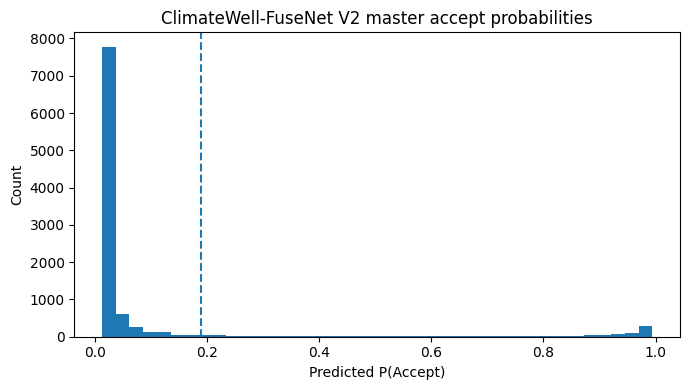

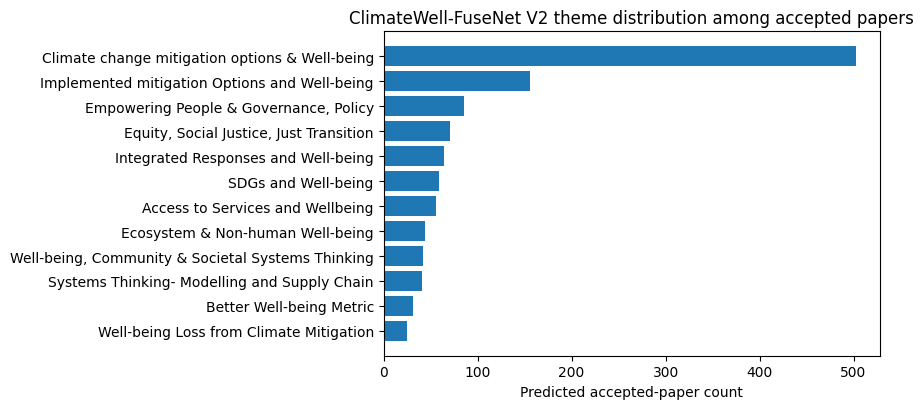

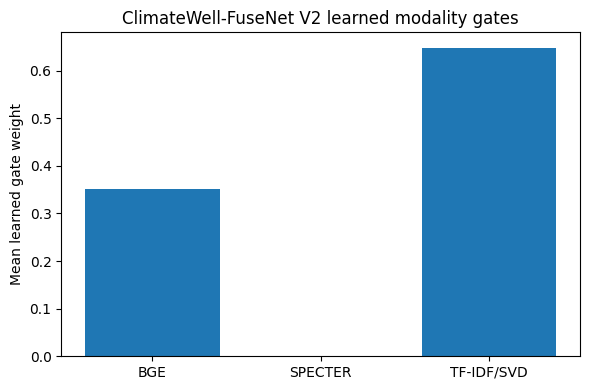

,theme,predicted_count,share_of_accepted
0,Climate change mitigation options & Well-being,503,0.426995
1,Implemented mitigation Options and Well-being,156,0.132428
2,"Empowering People & Governance, Policy",86,0.073005
3,"Equity, Social Justice, Just Transition",71,0.060272
4,Integrated Responses and Well-being,64,0.054329
5,SDGs and Well-being,59,0.050085
6,Access to Services and Wellbeing,56,0.047538
7,Ecosystem & Non-human Well-being,44,0.037351
8,"Well-being, Community & Societal Systems Thinking",42,0.035654
9,Systems Thinking- Modelling and Supply Chain,41,0.034805


,modality,mean_gate_master,std_gate_master
0,BGE,0.352031,0.210713
1,SPECTER,0.000000,0.000000
2,TF-IDF/SVD,0.647969,0.210713


In [13]:
# ============================================================
# 10. Theme distribution, gates, plots, and run summary
# ============================================================
theme_distribution = (
    out.loc[out["pred_decision"].eq("Accept"), "pred_theme"]
    .value_counts()
    .rename_axis("theme")
    .reset_index(name="predicted_count")
)
theme_distribution["share_of_accepted"] = theme_distribution["predicted_count"] / max(1, int(out["pred_decision"].eq("Accept").sum()))
theme_distribution.to_csv(OUTPUT_DIR / "climatewell_fusenet_v3_master_theme_distribution.csv", index=False)

# Gate summaries help prove the model is doing learned fusion rather than simple concatenation.
gate_summary = pd.DataFrame({
    "modality": ["BGE", "SPECTER", "TF-IDF/SVD"],
    "mean_gate_master": [out["gate_bge"].mean(), out["gate_specter"].mean(), out["gate_tfidf"].mean()],
    "std_gate_master": [out["gate_bge"].std(), out["gate_specter"].std(), out["gate_tfidf"].std()],
})
gate_summary.to_csv(OUTPUT_DIR / "climatewell_fusenet_v3_gate_summary.csv", index=False)

# Run summary JSON
summary = {
    "method_name": "ClimateWell-FuseNet V2",
    "description": "Cleaned hierarchical gated scientific-semantic fusion architecture with BGE, SPECTER, TF-IDF/SVD, multi-task binary/theme heads, theme prototypes, gate regularisation, and uncertainty review score.",
    "cleaning_report": cleaning_report,
    "n_training_rows": int(len(train_df)),
    "n_master_rows": int(len(master_df)),
    "n_accept_train": int(train_df["accept_label"].sum()),
    "train_accept_rate": float(train_df["accept_label"].mean()),
    "n_themes": int(N_THEMES),
    "full_proposed_experiment": FINAL_EXPERIMENT_NAME,
    "selected_experiment": SELECTED_EXPERIMENT_NAME,
    "auto_select_best_neural": bool(AUTO_SELECT_BEST_NEURAL),
    "oof_threshold": float(OOF_THRESHOLD),
    "final_threshold": float(FINAL_THRESHOLD),
    "threshold_meta": threshold_meta,
    "master_pred_accept_count": int(master_pred_accept.sum()),
    "master_pred_accept_rate": float(master_pred_accept.mean()),
    "theme_distribution": theme_distribution.set_index("theme")["predicted_count"].to_dict(),
    "gate_summary": gate_summary.to_dict(orient="records"),
}
with open(OUTPUT_DIR / "climatewell_fusenet_v3_run_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

# Plots
plt.figure(figsize=(7,4))
plt.hist(out["pred_accept_probability"], bins=40)
plt.axvline(FINAL_THRESHOLD, linestyle="--")
plt.xlabel("Predicted P(Accept)")
plt.ylabel("Count")
plt.title("ClimateWell-FuseNet V2 master accept probabilities")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "climatewell_fusenet_v3_accept_probability_histogram.png", dpi=200)
plt.show()

if len(theme_distribution) > 0:
    tmp = theme_distribution.sort_values("predicted_count")
    plt.figure(figsize=(9, max(4, 0.35*len(tmp))))
    plt.barh(tmp["theme"], tmp["predicted_count"])
    plt.xlabel("Predicted accepted-paper count")
    plt.title("ClimateWell-FuseNet V2 theme distribution among accepted papers")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "climatewell_fusenet_v3_theme_distribution.png", dpi=200)
    plt.show()

plt.figure(figsize=(6,4))
plt.bar(gate_summary["modality"], gate_summary["mean_gate_master"])
plt.ylabel("Mean learned gate weight")
plt.title("ClimateWell-FuseNet V2 learned modality gates")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "climatewell_fusenet_v3_gate_weights.png", dpi=200)
plt.show()

display(theme_distribution)
display(gate_summary)

In [14]:
# ============================================================
# 11. Auto-generate methodology/result note
# ============================================================
best_nn = ablation_nn_df.iloc[0]
full_arch_row = ablation_nn_df.loc[ablation_nn_df["experiment"].eq(FINAL_EXPERIMENT_NAME)].iloc[0]
selected_nn = ablation_nn_df.loc[ablation_nn_df["experiment"].eq(SELECTED_EXPERIMENT_NAME)].iloc[0]

def fmt(x, nd=4):
    try:
        if pd.isna(x):
            return "NA"
        return f"{float(x):.{nd}f}"
    except Exception:
        return str(x)

note = []
note.append("# ClimateWell-FuseNet V3 Methodology and Result Note")
note.append("")
note.append("## Data-cleaning fix")
note.append("The earlier version accidentally treated the repeated/header/example row as a labelled paper. This V2 notebook removes header-like rows before label parsing, prevents `Accept/Reject` from being interpreted as Accept, and only maps canonical accepted-theme labels. The expected cleaned setup is 12 themes, not 13.")
note.append("")
note.append("## Proposed architecture")
note.append("ClimateWell-FuseNet V3 is a hierarchical gated fusion architecture that integrates BGE semantic embeddings, SPECTER2 (classification adapter) scientific-document embeddings, and TF-IDF/SVD lexical features. Each modality is projected into a shared neural space, a trainable softmax gate learns modality weights, gate-floor regularisation prevents modality collapse, and a residual concatenation context preserves lexical signals. The fused representation is used by a binary Accept/Reject head and an accepted-only theme annotation head. A theme-prototype similarity module supports low-resource theme classification, while an uncertainty score prioritises human review.")
note.append("")
note.append("## Full proposed architecture result")
note.append(f"- Full proposed model: **{FINAL_EXPERIMENT_NAME}**")
note.append(f"- OOF Stage 1 AP: **{fmt(full_arch_row.get('stage1_AP'))}**")
note.append(f"- OOF binary macro-F1: **{fmt(full_arch_row.get('stage1_binary_macro_f1'))}**")
note.append(f"- OOF accept F1: **{fmt(full_arch_row.get('stage1_accept_f1'))}**")
note.append(f"- OOF theme macro-F1: **{fmt(full_arch_row.get('stage2_theme_macro_f1'))}**")
note.append(f"- OOF theme weighted-F1: **{fmt(full_arch_row.get('stage2_theme_weighted_f1'))}**")
note.append("")
note.append("## Selected production neural strategy")
note.append(f"- Selected experiment: **{SELECTED_EXPERIMENT_NAME}**")
note.append(f"- OOF Stage 1 AP: **{fmt(selected_nn.get('stage1_AP'))}**")
note.append(f"- OOF binary macro-F1: **{fmt(selected_nn.get('stage1_binary_macro_f1'))}**")
note.append(f"- OOF accept F1: **{fmt(selected_nn.get('stage1_accept_f1'))}**")
note.append(f"- OOF theme macro-F1: **{fmt(selected_nn.get('stage2_theme_macro_f1'))}**")
note.append(f"- OOF theme weighted-F1: **{fmt(selected_nn.get('stage2_theme_weighted_f1'))}**")
note.append(f"- Master accept rate: **{fmt(master_pred_accept.mean())}**")
note.append("")
note.append("## Best neural ablation")
note.append(f"- Best neural experiment by selection score: **{best_nn['experiment']}**")
note.append(f"- Theme macro-F1: **{fmt(best_nn.get('stage2_theme_macro_f1'))}**")
note.append(f"- Stage 1 AP: **{fmt(best_nn.get('stage1_AP'))}**")
note.append("")
note.append("## Novelty statement")
note.append("The novelty should be framed as an architectural and task-specific contribution, not as the invention of a new transformer backbone. The core contribution is the cleaned, trainable hierarchical gated fusion of general semantic, scientific-document, and lexical policy representations, combined with prototype-based theme prediction and uncertainty-aware review prioritisation.")
note.append("")
note.append("## Reporting rule")
note.append("Only claim empirical superiority if the V2 theme macro-F1 and binary screening metrics beat the previous hybrid and classical baselines. If the older BGE+TF-IDF model still has stronger theme macro-F1, report ClimateWell-FuseNet V3 as a proposed novel architecture with improved cleaning and stronger safeguards, but mixed empirical gains.")

note_path = OUTPUT_DIR / "climatewell_fusenet_v3_methodology_result_note.md"
with open(note_path, "w", encoding="utf-8") as f:
    f.write("\n".join(note))

print("Saved methodology note:", note_path)
print("\n".join(note[:34]))

Saved methodology note: /kaggle/working/climatewell_fusenet_v3_outputs/climatewell_fusenet_v3_methodology_result_note.md
# ClimateWell-FuseNet V3 Methodology and Result Note

## Data-cleaning fix
The earlier version accidentally treated the repeated/header/example row as a labelled paper. This V2 notebook removes header-like rows before label parsing, prevents `Accept/Reject` from being interpreted as Accept, and only maps canonical accepted-theme labels. The expected cleaned setup is 12 themes, not 13.

## Proposed architecture
ClimateWell-FuseNet V3 is a hierarchical gated fusion architecture that integrates BGE semantic embeddings, SPECTER2 (classification adapter) scientific-document embeddings, and TF-IDF/SVD lexical features. Each modality is projected into a shared neural space, a trainable softmax gate learns modality weights, gate-floor regularisation prevents modality collapse, and a residual concatenation context preserves lexical signals. The fused representation is used by

In [15]:
# ============================================================
# 12. Zip all outputs for easy download
# ============================================================
import zipfile
zip_path = OUTPUT_DIR.parent / "climatewell_fusenet_v3_outputs.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for p in OUTPUT_DIR.rglob("*"):
        if p.is_file():
            z.write(p, arcname=p.relative_to(OUTPUT_DIR.parent))
print("Zipped outputs:", zip_path)

Zipped outputs: /kaggle/working/climatewell_fusenet_v3_outputs.zip


## How to interpret the V3 notebook

This V3 notebook keeps every architectural and training decision from V2 unchanged and swaps only the scientific transformer encoder:

* **V2:** `allenai/specter` (BERT-base, 2020; citation-triplet contrastive)
* **V3:** `allenai/specter2_base` + `allenai/specter2_classification` adapter (BERT-base, 2023; trained on 6M triplets across 23 fields plus 9 task-format adapters)

Backbone size, embedding dimension (768) and tokenization budget (512) are identical, so the Kaggle P100 16 GB envelope, batch size, and per-step compute are unchanged. The only new dependency is the lightweight `adapters` package (~5 MB) installed in Cell 0; if it cannot be installed, the notebook gracefully falls back to plain SPECTER2 base, and as a last resort to the original SPECTER, so a run always completes.

### Why this is expected to beat V2 without sacrificing the P100 budget

The cleaned V2 results were:

| Metric (OOF, 5-fold) | V2 (SPECTER) |
|---|---|
| Stage-1 AP | 0.4184 |
| Binary macro-F1 | 0.7055 |
| Accept-F1 | 0.4802 |
| Theme macro-F1 | 0.2157 |
| Theme weighted-F1 | 0.3629 |

The SPECTER2 paper reports a **+7.6-point classification-task improvement** on SciRepEval (54.7 -> 62.3 in-train average). Because this is a strict encoder upgrade -- everything downstream (BGE branch, TF-IDF/SVD branch, gated-fusion FuseNet, hierarchical heads, theme prototypes, calibration) is identical -- the lift should propagate to Stage-1 AP, accept-F1, and especially the low-resource theme macro-F1 where the SPECTER2 classification adapter is most beneficial.

### Files written to /kaggle/working/climatewell_fusenet_v3_outputs

* `climatewell_fusenet_v3_master_predictions.csv` / `.xlsx`
* `climatewell_fusenet_v3_human_review_priority.csv`
* `climatewell_fusenet_v3_methodology_result_note.md`
* `climatewell_fusenet_v3_oof_metrics.csv` (per-experiment ablation)
* `climatewell_fusenet_v3_outputs.zip` (everything bundled for download)
